<a href="https://colab.research.google.com/github/harshitachitturi245-debug/data_analytics_intern-veda-technology-/blob/main/Copy_of_Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload your Supermarket Sales CSV file:


Saving supermarket_sales_dataset.csv to supermarket_sales_dataset.csv

Dataset loaded successfully!
Rows: 30
Columns: 12

Column Names:
['Order_ID', 'Date', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales', 'Payment', 'City', 'Customer_Type', 'Discount', 'Profit']

================ KPI SUMMARY ================
Total Sales       : 15075
Total Profit      : 2400
Total Quantity    : 164
Total Orders      : 30
Average Order     : 502.5
Profit Margin (%) : 15.92

================ SALES BY CATEGORY ================
        Category  Total_Sales  Total_Quantity  Total_Profit
4        Grocery         3910              22           565
7  Personal Care         2475              30           425
8         Snacks         1810              45           335
3         Fruits         1680              12           240
6           Meat         1400               5           210
5      Household         1320               6           205
2          Dairy         1320              19      

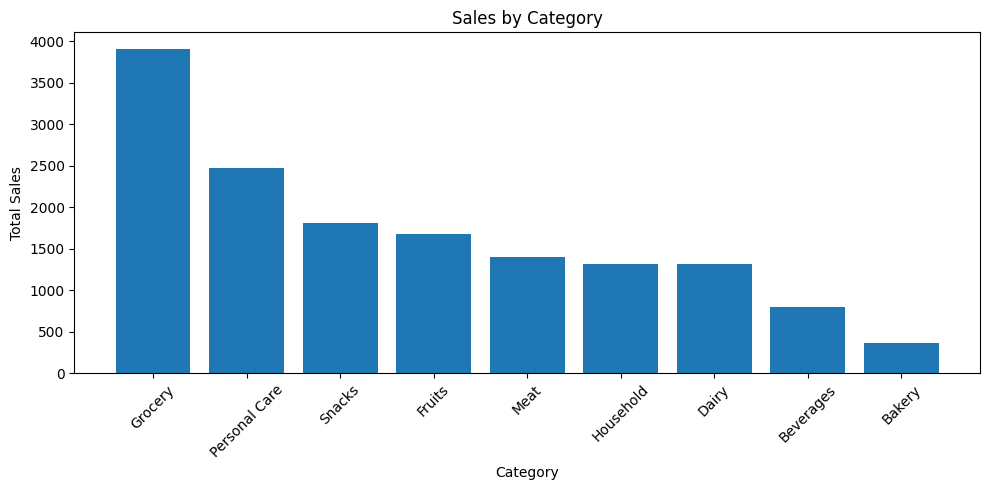

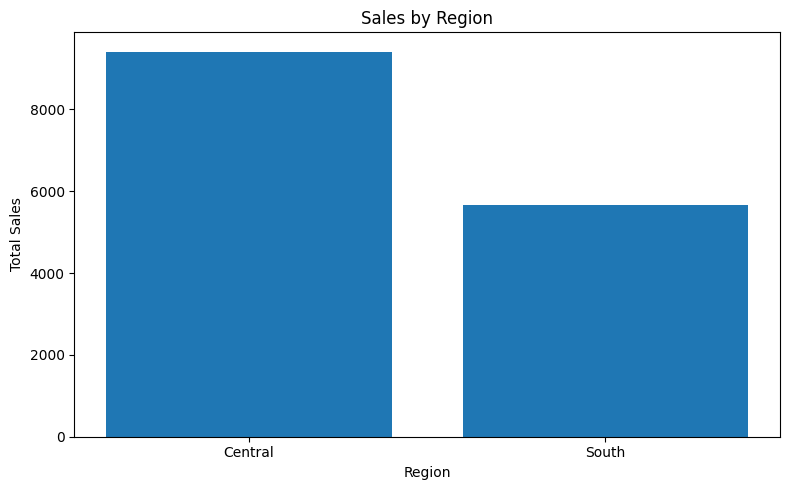

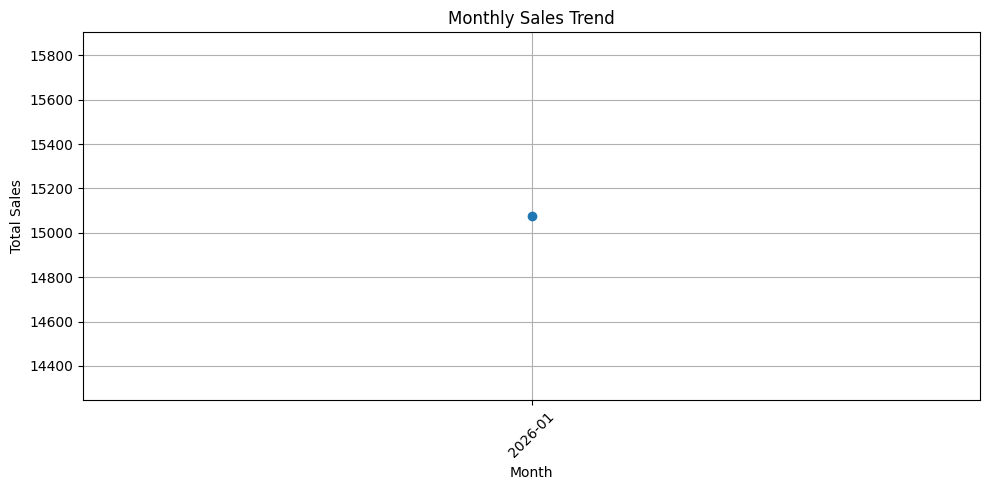


PROJECT COMPLETED SUCCESSFULLY!
Excel report created: Supermarket_Sales_Internship_Report.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# ============================================================
# SUPERMARKET SALES ANALYSIS - INTERNSHIP TASK
# ============================================================

# Install / import required libraries
!pip -q install pandas openpyxl matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import BarChart, LineChart, Reference

# ------------------------------------------------------------
# 1. UPLOAD DATASET
# ------------------------------------------------------------
print("Upload your Supermarket Sales CSV file:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# ------------------------------------------------------------
# 2. CLEAN COLUMN NAMES
# ------------------------------------------------------------
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nColumn Names:")
print(list(df.columns))

# ------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Total_Sales",
    "Discount",
    "Profit"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove completely empty rows
df = df.dropna(how="all")

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numeric values with 0
for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fill missing text values
for col in ["Product", "Category", "Payment", "City", "Customer_Type"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# ------------------------------------------------------------
# 4. CREATE REGION COLUMN
# ------------------------------------------------------------
# This creates regions from cities if Region does not already exist.
# You can change these mappings according to your actual dataset.

if "Region" not in df.columns:

    region_map = {
        "Vijayawada": "Central",
        "Guntur": "Central",
        "Nellore": "South",
        "Hyderabad": "Telangana",
        "Visakhapatnam": "North",
        "Tirupati": "South",
        "Kurnool": "West",
        "Rajahmundry": "East"
    }

    df["Region"] = df["City"].map(region_map).fillna("Other")

# ------------------------------------------------------------
# 5. CREATE MONTH COLUMN
# ------------------------------------------------------------
df["Month"] = df["Date"].dt.to_period("M").astype(str)

df["Month_Name"] = df["Date"].dt.strftime("%B")

# ------------------------------------------------------------
# 6. BASIC KPI ANALYSIS
# ------------------------------------------------------------
total_sales = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order_ID"].nunique()

average_order_value = (
    total_sales / total_orders
    if total_orders > 0 else 0
)

profit_margin = (
    total_profit / total_sales * 100
    if total_sales > 0 else 0
)

print("\n================ KPI SUMMARY ================")
print("Total Sales       :", round(total_sales, 2))
print("Total Profit      :", round(total_profit, 2))
print("Total Quantity    :", total_quantity)
print("Total Orders      :", total_orders)
print("Average Order     :", round(average_order_value, 2))
print("Profit Margin (%) :", round(profit_margin, 2))

# ------------------------------------------------------------
# 7. SALES BY CATEGORY
# ------------------------------------------------------------
sales_by_category = (
    df.groupby("Category", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n================ SALES BY CATEGORY ================")
print(sales_by_category)

# ------------------------------------------------------------
# 8. SALES BY REGION
# ------------------------------------------------------------
sales_by_region = (
    df.groupby("Region", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n================ SALES BY REGION ================")
print(sales_by_region)

# ------------------------------------------------------------
# 9. MONTHLY SALES TREND
# ------------------------------------------------------------
monthly_sales = (
    df.groupby("Month", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Month")
)

print("\n================ MONTHLY SALES ================")
print(monthly_sales)

# ------------------------------------------------------------
# 10. SALES BY PRODUCT
# ------------------------------------------------------------
sales_by_product = (
    df.groupby("Product", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n================ TOP PRODUCTS ================")
print(sales_by_product.head(10))

# ------------------------------------------------------------
# 11. SALES BY PAYMENT METHOD
# ------------------------------------------------------------
payment_analysis = (
    df.groupby("Payment", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n================ PAYMENT ANALYSIS ================")
print(payment_analysis)

# ------------------------------------------------------------
# 12. CUSTOMER TYPE ANALYSIS
# ------------------------------------------------------------
customer_analysis = (
    df.groupby("Customer_Type", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("\n================ CUSTOMER ANALYSIS ================")
print(customer_analysis)

# ------------------------------------------------------------
# 13. BEST CATEGORY
# ------------------------------------------------------------
best_category = sales_by_category.iloc[0]

# ------------------------------------------------------------
# 14. BEST REGION
# ------------------------------------------------------------
best_region = sales_by_region.iloc[0]

# ------------------------------------------------------------
# 15. BEST PRODUCT
# ------------------------------------------------------------
best_product = sales_by_product.iloc[0]

print("\n================ BUSINESS INSIGHTS ================")

print(
    f"Best Category: {best_category['Category']} "
    f"with sales of {best_category['Total_Sales']:.2f}"
)

print(
    f"Best Region: {best_region['Region']} "
    f"with sales of {best_region['Total_Sales']:.2f}"
)

print(
    f"Best Product: {best_product['Product']} "
    f"with sales of {best_product['Total_Sales']:.2f}"
)

# ------------------------------------------------------------
# 16. CREATE EXCEL REPORT
# ------------------------------------------------------------
output_file = "Supermarket_Sales_Internship_Report.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # Raw data - untouched copy
    df.to_excel(
        writer,
        sheet_name="Raw_Data",
        index=False
    )

    # KPI
    kpi_df = pd.DataFrame({
        "KPI": [
            "Total Sales",
            "Total Profit",
            "Total Quantity",
            "Total Orders",
            "Average Order Value",
            "Profit Margin (%)"
        ],
        "Value": [
            total_sales,
            total_profit,
            total_quantity,
            total_orders,
            average_order_value,
            profit_margin
        ]
    })

    kpi_df.to_excel(
        writer,
        sheet_name="KPI",
        index=False
    )

    # Analysis sheets
    sales_by_category.to_excel(
        writer,
        sheet_name="Sales_by_Category",
        index=False
    )

    sales_by_region.to_excel(
        writer,
        sheet_name="Sales_by_Region",
        index=False
    )

    monthly_sales.to_excel(
        writer,
        sheet_name="Monthly_Sales",
        index=False
    )

    sales_by_product.to_excel(
        writer,
        sheet_name="Sales_by_Product",
        index=False
    )

    payment_analysis.to_excel(
        writer,
        sheet_name="Payment_Analysis",
        index=False
    )

    customer_analysis.to_excel(
        writer,
        sheet_name="Customer_Analysis",
        index=False
    )

# ------------------------------------------------------------
# 17. FORMAT EXCEL WORKBOOK
# ------------------------------------------------------------
wb = load_workbook(output_file)

for ws in wb.worksheets:

    # Freeze first row
    ws.freeze_panes = "A2"

    # Make headers bold
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center")

    # Automatically adjust column widths
    for column in ws.columns:
        max_length = 0
        column_letter = column[0].column_letter

        for cell in column:
            try:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )
            except:
                pass

        ws.column_dimensions[column_letter].width = min(
            max_length + 2,
            30
        )

# Save formatted workbook
wb.save(output_file)

# ------------------------------------------------------------
# 18. DISPLAY CHARTS
# ------------------------------------------------------------

# Category Sales Chart
plt.figure(figsize=(10,5))
plt.bar(
    sales_by_category["Category"],
    sales_by_category["Total_Sales"]
)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Region Sales Chart
plt.figure(figsize=(8,5))
plt.bar(
    sales_by_region["Region"],
    sales_by_region["Total_Sales"]
)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# Monthly Sales Trend
plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales["Month"],
    monthly_sales["Total_Sales"],
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 19. DOWNLOAD FINAL REPORT
# ------------------------------------------------------------
print("\n================================================")
print("PROJECT COMPLETED SUCCESSFULLY!")
print("================================================")
print("Excel report created:", output_file)

files.download(output_file)